# NBA Scheduling Analysis

**A modeling experiment investigating league scheduling trends and measuring the impact of the NBA's fairness initiatives**

Bridget Muñoz · June 2026

**Topics of Interest**

- How NBA scheduling has changed over the past decade
- Which schedule situations make a game winnable versus nearly lost
- The travel burden that geography forces on certain teams
- Whether the league's fairness reforms actually equalized schedules
- How multicollinearity shapes modeling results uniquely for sports data analysis and modeling

## Data Collection, Usage, and Transformation

- **Sample:** All regular-season game logs from the 13-14 season to the 25-26 season, pulled from `nba_api`.
- **Given variables:** date, team, matchup (opponent + home/away), and result
- Each game arrives from `nba_api` as the following variables: the date, the two teams, who was home, and the result (W/L). These factors alone cannot holistically predict schedule difficulty. The intention of this project is to display the ways that only a few raw variables can be transformed and visualized, and to support the claim that games are won mostly by ability rather than an easier schedule.

**This project turns 4 raw variables (date, team, matchup, result) into 10 engineered features covering rest, travel, opponent quality, and game context.**

| Category | Engineered features | # |
|---|---|---|
| **Rest** | `rest_days`, `is_b2b`, `is_3in4`, `is_4in6` | 4 |
| **Travel** | `consecutive_away_games`, `days_since_home_game`, `travel_distance` | 3 |
| **Opponent quality** | `opp_prior_win_pct` | 1 |
| **Game context** | `is_away`, `is_nonconference` | 2 |

Every feature is taken from the schedule itself (plus each team's home-city coordinates for travel), with no box-score or in-game stats considered. Nine of these feed the predictive model in Section Five; travel distance powers the travel and fairness analysis in Sections Three and Four.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_schedule, DEFAULT_SEASONS
from model import (
    train_sds_model, score_sds, coefficient_table,
    schedule_driven_wins, ALL_FEATURES,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']

# the 4 raw fields per game
sched = load_schedule(DEFAULT_SEASONS)


In [2]:
import numpy as np
import pandas as pd
from data import TEAM_LOCATION

def rolling_count_in_window(dates, window_days):
    # games in the last N days
    s = pd.Series(1, index=pd.DatetimeIndex(dates))
    return s.rolling(f"{window_days}D").sum().values.astype(int)


def add_rest(df):
    # rest: days off, b2b, 3-in-4, 4-in-6
    out = df.sort_values(["season", "team", "gamedate"]).copy()
    grp = out.groupby(["season", "team"], sort=False)
    out["rest_days"] = grp["gamedate"].diff().dt.days
    out["is_b2b"] = (out["rest_days"] == 1).astype(int)
    c6 = grp["gamedate"].transform(lambda s: rolling_count_in_window(s, 6))
    c4 = grp["gamedate"].transform(lambda s: rolling_count_in_window(s, 4))
    out["is_4in6"] = (c6 >= 4).astype(int)
    out["is_3in4"] = (c4 >= 3).astype(int)
    return out


def add_travel(df):
    # travel: road trip length, days since home
    out = df.copy()
    out["is_away"] = (1 - out["home"]).astype(int)
    out = out.sort_values(["season", "team", "gamedate"]).reset_index(drop=True)
    away = out["is_away"].values
    key = (out["season"].astype(str) + "|" + out["team"]).values
    trip = np.zeros(len(out), dtype=int); prev = None; run = 0
    for i in range(len(out)):
        if key[i] != prev: run = 0; prev = key[i]
        run = run + 1 if away[i] else 0; trip[i] = run
    out["consecutive_away_games"] = trip
    days = np.zeros(len(out), dtype=int); last = {}
    for i in range(len(out)):
        k = key[i]
        if away[i] == 0: last[k] = out["gamedate"].iloc[i]; days[i] = 0
        else:
            lh = last.get(k); days[i] = 0 if lh is None else (out["gamedate"].iloc[i] - lh).days
    out["days_since_home_game"] = days
    return out


def haversine(la1, lo1, la2, lo2):
    R = 3959.0; p = np.pi / 180
    a = np.sin((la2-la1)*p/2)**2 + np.cos(la1*p)*np.cos(la2*p)*np.sin((lo2-lo1)*p/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def add_travel_distance(df):
    # miles flown from the previous game's city to this one
    lat = {t: v[0] for t, v in TEAM_LOCATION.items()}; lon = {t: v[1] for t, v in TEAM_LOCATION.items()}
    out = df.sort_values(["season", "team", "gamedate"]).reset_index(drop=True)
    host = np.where(out["home"] == 1, out["team"], out["opponent"])
    out["_glat"] = pd.Series(host, index=out.index).map(lat)
    out["_glon"] = pd.Series(host, index=out.index).map(lon)
    g = out.groupby(["season", "team"], sort=False)
    out["travel_distance"] = haversine(g["_glat"].shift(), g["_glon"].shift(), out["_glat"], out["_glon"])
    return out.drop(columns=["_glat", "_glon"])


def add_opp_prior_win_pct(df):
    # opponent's win pct going in
    out = df.sort_values(["season", "team", "gamedate"]).copy()
    grp = out.groupby(["season", "team"], sort=False)
    pw = grp["win"].cumsum() - out["win"]; pg = grp.cumcount()
    out["_p"] = np.where(pg > 0, pw / pg, np.nan)
    look = out[["season", "team", "gamedate", "_p"]].rename(columns={"team": "opponent", "_p": "opp_prior_win_pct"})
    m = out.merge(look, on=["season", "opponent", "gamedate"], how="left").drop(columns="_p")
    return m.sort_values(["season", "team", "gamedate"]).reset_index(drop=True)


def build_features(schedule):
    out = add_rest(schedule)
    out = add_travel(out)
    out = add_travel_distance(out)
    out = add_opp_prior_win_pct(out)
    out["is_nonconference"] = out["is_nonconf"]
    return out


feats = build_features(sched)
print(f'{len(feats):,} team-games across {feats["season"].nunique()} seasons')


31,338 team-games across 13 seasons


## Section One: Scheduling Trends from 13-14 to 25-26 Seasons

The NBA has actively worked to reduce back-to-backs and 4-in-6 stretches over the past decade. The chart below shows whether these efforts have succeeded, tracking three per-season averages across team-seasons (% of games that are the second night of a back-to-back, % that fall inside a 4-in-6 stretch, and % that cross conferences).

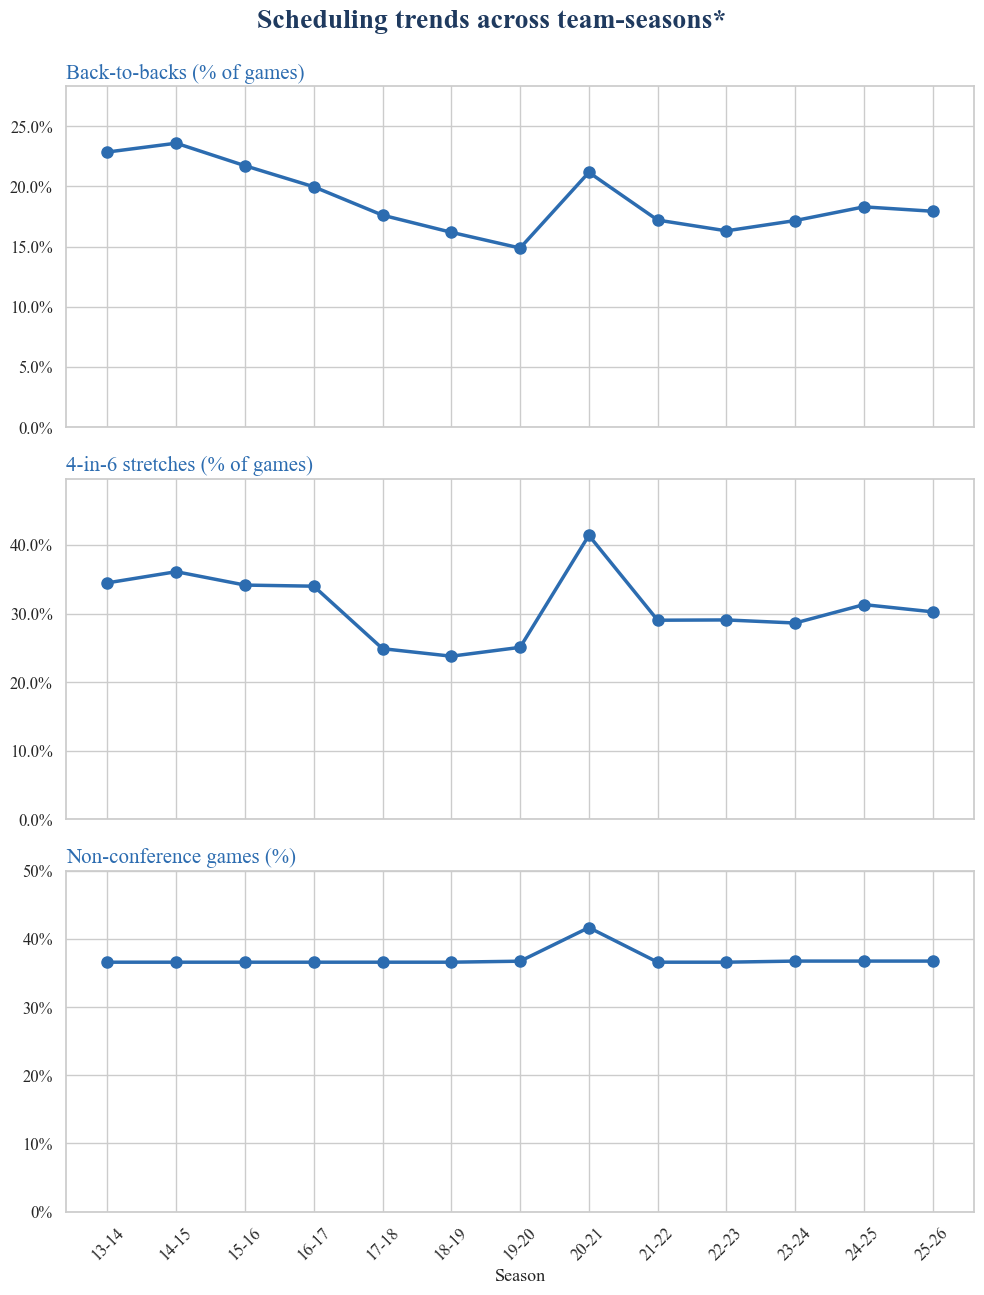

In [3]:
from matplotlib.ticker import PercentFormatter

trend = (
    feats.groupby('season')[['is_b2b', 'is_4in6', 'is_nonconf']]
    .mean()
    .reset_index()
)
trend['season_short'] = trend['season'].str[2:]  # 2013-14 -> 13-14

# stacked so each panel is full width
fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharex=True)
for ax, col, title in zip(
    axes,
    ['is_b2b', 'is_4in6', 'is_nonconf'],
    ['Back-to-backs (% of games)',
     '4-in-6 stretches (% of games)',
     'Non-conference games (%)'],
):
    ax.plot(trend['season_short'], trend[col], marker='o', linewidth=2.5,
            markersize=8, color='#2c6cb0')
    ax.set_title(title, fontsize=15, loc='left', color='#2c6cb0')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_ylim(0, max(trend[col].max() * 1.2, 0.05))
    ax.tick_params(axis='both', labelsize=12)
axes[-1].set_xlabel('Season', fontsize=13)
axes[-1].tick_params(axis='x', rotation=45)
fig.suptitle('Scheduling trends across team-seasons*', y=0.995,
             fontsize=20, weight='bold', color='#1f3a5f')
plt.tight_layout()
plt.show()


<p class="figure-note">* These charts measure the <strong>percentage of all regular-season team-games, league-wide</strong>, that fall into each category, by season. The dataset has one row per team per game, so every team is weighted equally (~82 games each). For example, "back-to-backs" is the share of team-games played on the second night of a back-to-back.</p>

The decrease in back-to-backs and 4-in-6 stretches is consistent with the league's goal. Additionally, you can see how the COVID season impacted scheduling in these charts. Non-conference share is consistent besides the bubble. The proportion of 4-in-6 and back-to-back stretches seem to align with each other, both steadily decreasing until the COVID season, sharp increase, then staying stagnant in following seasons.

## Section Two: Which Games Are Winnable

The schedule barely moves a team's season record, but at the single-game level it swings win probability a lot. The chart below shows win rate by schedule situation, from rested home games against weak teams to tired road games against strong ones. An additional test confirms these differences are not just due to chance (see the statistical analysis).

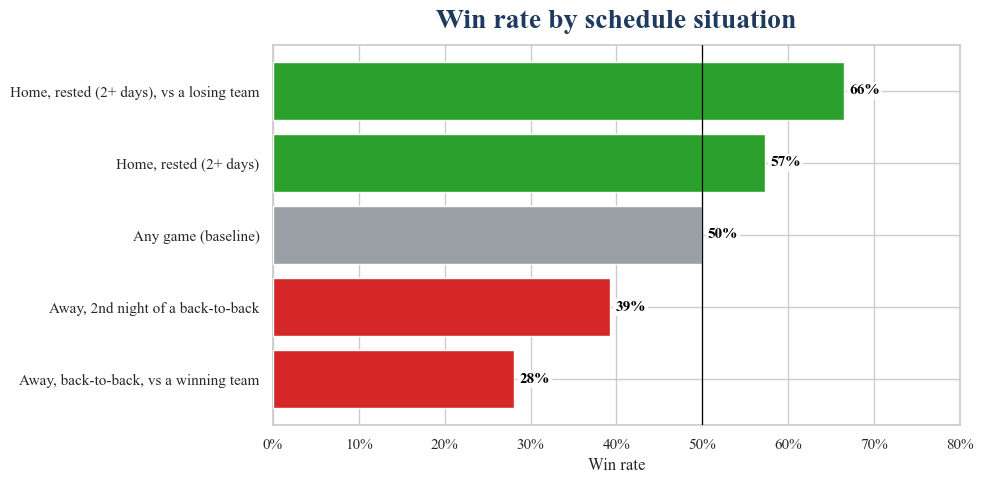

In [4]:
from matplotlib.ticker import PercentFormatter

d = feats.dropna(subset=['rest_days']).copy()
spots = [
    ('Home, rested (2+ days), vs a losing team', (d.home==1) & (d.rest_days>=2) & (d.opp_prior_win_pct<0.5)),
    ('Home, rested (2+ days)',                    (d.home==1) & (d.rest_days>=2)),
    ('Any game (baseline)',                       d.index==d.index),
    ('Away, 2nd night of a back-to-back',         (d.is_away==1) & (d.is_b2b==1)),
    ('Away, back-to-back, vs a winning team',     (d.is_away==1) & (d.is_b2b==1) & (d.opp_prior_win_pct>0.5)),
]
res = (pd.DataFrame([(lab, d[m]['win'].mean(), int(pd.Series(m).sum())) for lab, m in spots],
                    columns=['spot','winrate','n']).sort_values('winrate'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)
colors = ['#9aa0a6' if 'baseline' in s else ('#2ca02c' if w>0.5 else '#d62728')
          for s, w in zip(res.spot, res.winrate)]
bars = ax.barh(res.spot, res.winrate, color=colors, zorder=3)
ax.axvline(0.5, color='black', linewidth=0.9, zorder=4)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlim(0, 0.8)
lbls = ax.bar_label(bars, labels=[f'{w*100:.0f}%' for w in res.winrate],
                    padding=4, fontsize=11, fontweight='bold', color='black')
for t in lbls:
    t.set_zorder(6); t.set_bbox(dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.9))
ax.set_xlabel('Win rate')
ax.set_title('Win rate by schedule situation', loc='center', fontsize=20, weight='bold', color='#1f3a5f', pad=12)
plt.tight_layout()
plt.show()

# chi-square: best vs worst spot
from scipy import stats as _stats
_best  = d[(d.home == 1) & (d.rest_days >= 2) & (d.opp_prior_win_pct < 0.5)]['win']
_worst = d[(d.is_away == 1) & (d.is_b2b == 1) & (d.opp_prior_win_pct > 0.5)]['win']
_tbl = [[_best.sum(), len(_best) - _best.sum()], [_worst.sum(), len(_worst) - _worst.sum()]]
_chi2, _p, _, _ = _stats.chi2_contingency(_tbl)   # chi2 ~ 809, p ~ 0 -> not chance


<div class="stats-analysis">
<p><strong>Context.</strong> This data comes straight from the dataset and has not been modeled, just grouped and averaged by variable, the highs and lows are seen in the graph. Each bar is just the share of games won in that situation across all 13 seasons.</p>
<p><strong>Sample size.</strong></p>
<ul>
<li>Home, rested (2+ days), vs a losing team: n = 5,985</li>
<li>Home, rested (2+ days): n = 13,161</li>
<li>Any game (baseline): n = 30,948</li>
<li>Away, 2nd night of a back-to-back: n = 3,608</li>
<li>Away, back-to-back, vs a winning team: n = 1,736</li>
</ul>
<p>Because the outcome is binary (win or loss), I use a chi-square test. Comparing the best spot (66%) with the worst (28%) gives chi-square = 809, p &approx; 0, so the difference is not due to chance.</p>
</div>

## Section Three: The Travel Tax

Every team plays 82 games, but they don't fly the same distance to do it. Travel is mostly fixed by geography, so it's the one part of the schedule the league can't equalize. The chart below shows average miles flown per season by team, computed from each team's home-city coordinates.

POR flies 49,051 mi/season vs CLE at 35,905  ->  a 13,146 mile gap


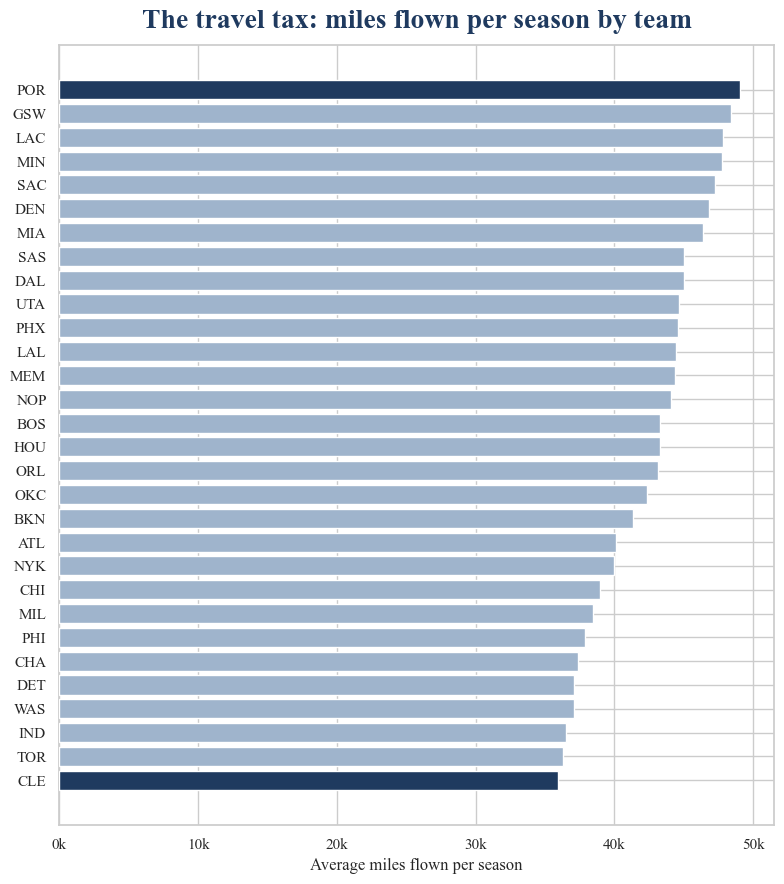

In [5]:
# anova: do teams differ in season travel?

from scipy import stats
from matplotlib.ticker import FuncFormatter

rec = feats[feats['season'] >= '2022-23'].dropna(subset=['travel_distance'])
season_tot = rec.groupby(['season', 'team'])['travel_distance'].sum().reset_index()
team_mi = season_tot.groupby('team')['travel_distance'].mean().sort_values()

groups = [v['travel_distance'].values for _, v in season_tot.groupby('team')]
F, pval = stats.f_oneway(*groups)
grand = season_tot['travel_distance'].mean()
ss_b = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
eta2 = ss_b / ((season_tot['travel_distance'] - grand) ** 2).sum()
print(f"{team_mi.idxmax()} flies {team_mi.max():,.0f} mi/season vs {team_mi.idxmin()} at "
      f"{team_mi.min():,.0f}  ->  a {team_mi.max()-team_mi.min():,.0f} mile gap")

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_axisbelow(True)
hi, lo = team_mi.idxmax(), team_mi.idxmin()
colors = ['#1f3a5f' if t in (hi, lo) else '#9fb4cc' for t in team_mi.index]
ax.barh(team_mi.index, team_mi.values, color=colors, zorder=3)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Average miles flown per season')
ax.set_title('The travel tax: miles flown per season by team', loc='center',
             fontsize=20, weight='bold', color='#1f3a5f', pad=12)
plt.tight_layout()
plt.show()


<div class="stats-analysis">
<p><strong>Confirmation through ANOVA:</strong> A one-way ANOVA across teams on season-total miles confirms this difference. The results gave F &approx; 11, p &approx; 7e-19, and eta-squared &approx; 0.78. The eta-squared here implies that ~ 78% of the variation in how distance flown by team is explained purely by which team it is. With this many games a small p-value is almost guaranteed, so effect size, not p, is the honest measure. 0.78 is more than meaningful to prove the difference in miles across teams.</p>
</div>

## Section Four: Did the Fairness Reforms Work?

The league set out to even out rest and congestion across teams. To check it, I measure how far each team sits from the league average in an early window (2013-14 to 2017-18) and a recent one (2022-23 to 2025-26), then see whether those gaps shrank.

Back-to-backs and 4-in-6 stretches both became meaningfully more even across teams. Travel shrank far less and not by a meaningful amount, which is the point: it is fixed by geography, not scheduling.

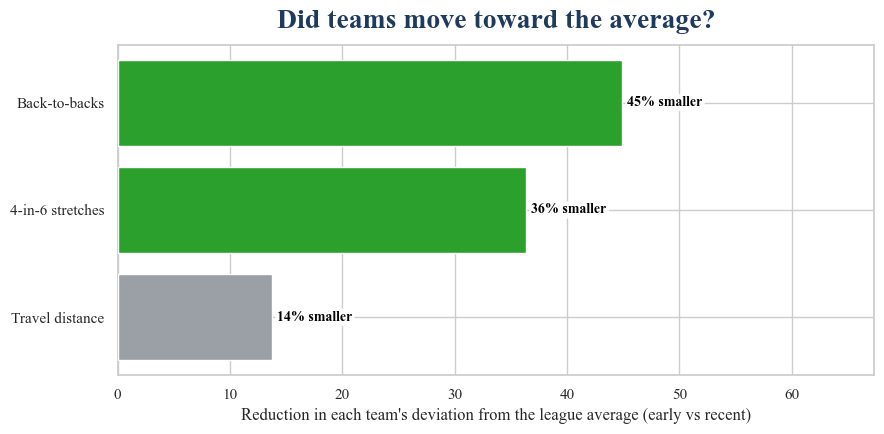

In [6]:
# paired one-sided wilcoxon on each team's deviation from the league average

from scipy import stats

early  = ['2013-14', '2014-15', '2015-16', '2016-17', '2017-18']
recent = ['2022-23', '2023-24', '2024-25', '2025-26']

def team_avg(seasons, col, agg):
    d = feats[feats['season'].isin(seasons)].dropna(subset=[col])
    if agg == 'sum':                       # season totals, averaged across seasons
        return d.groupby(['season', 'team'])[col].sum().groupby('team').mean()
    return d.groupby('team')[col].mean()

tests = [('is_b2b', 'mean', 'Back-to-backs'),
         ('is_4in6', 'mean', '4-in-6 stretches'),
         ('travel_distance', 'sum', 'Travel distance')]
rows = []
for col, agg, lab in tests:
    e, r = team_avg(early, col, agg), team_avg(recent, col, agg)
    t = e.index.intersection(r.index)
    dev_e = (e[t] - e[t].mean()).abs()     # each team's distance from the league average
    dev_r = (r[t] - r[t].mean()).abs()
    _, p = stats.wilcoxon(dev_e, dev_r, alternative='greater')   # one-sided: deviations shrank
    drop = (1 - dev_r.mean() / dev_e.mean()) * 100
    rows.append((lab, drop, p))

res = pd.DataFrame(rows, columns=['feature', 'reduction', 'p']).sort_values('reduction')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_axisbelow(True)
colors = ['#2ca02c' if p < 0.05 else '#9aa0a6' for p in res.p]   # green = significant
bars = ax.barh(res.feature, res.reduction, color=colors, zorder=3)
lbls = ax.bar_label(bars, labels=[f'{v:.0f}% smaller' for v in res.reduction],
                    padding=4, fontsize=10, fontweight='bold', color='black')
for tt in lbls:
    tt.set_zorder(6); tt.set_bbox(dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.9))
ax.set_xlim(0, max(res.reduction) * 1.5)
ax.set_xlabel("Reduction in each team's deviation from the league average (early vs recent)")
ax.set_title('Did teams move toward the average?', loc='center',
             fontsize=20, weight='bold', color='#1f3a5f', pad=12)
plt.tight_layout()
plt.show()


<div class="stats-analysis">
<p><strong>The test.</strong> For each feature I take every team's absolute deviation from the league average in the early window and the recent window, then run a paired, one-sided Wilcoxon signed-rank test. Paired because the same 30 teams appear in both windows; rank-based because n = 30 and the deviations are not assumed normal; one-sided because the league set out specifically to reduce congestion.</p>
<p><strong>Results.</strong> Back-to-backs: 45% smaller, p = 0.009. 4-in-6: 36% smaller, p = 0.035. Travel: 14% smaller, p = 0.073. With three tests a Bonferroni cutoff is 0.05 / 3 = 0.0167, so back-to-backs clears it, 4-in-6 is significant only before correction, and travel is not significant.</p>
</div>

## Section Five: Predicting Game Difficulty

The schedule-difficulty score (SDS) is a logistic regression fit to one row per team-game. The model's target is to predict whether a given team wins or loses a given game solely based on scheduling factors. Each factor is learned from existing game results. The model measures how each variable shifts the outcome of a given game. For example, playing a back-to-back (when the B2B variable flips from 0 to 1) raises a team's odds of losing that game by about 24%. Features and their impacts are listed below.

The model is trained on the 2013-14 through 2023-24 seasons (eleven full regular seasons), then used to score each game of the most recent season. Each game's SDS equals the model's predicted probability that the team loses. A higher SDS implies a tougher game for a team based on these factors.

Because the schedule is now so equitably distributed, team quality dominates the outcome. Playing on the road is the biggest scheduling factor, but even that matters less than who you're playing against.

In [7]:
train_seasons = DEFAULT_SEASONS[:-1]
score_season = DEFAULT_SEASONS[-1]

model = train_sds_model(feats, train_seasons)
scored = score_sds(model, feats[feats['season'] == score_season])

coefs = coefficient_table(model)
coefs.style.format({'coef': '{:.3f}', 'odds_ratio': '{:.2f}'}).background_gradient(
    subset=['coef'], cmap='RdBu_r', vmin=-0.7, vmax=0.7
)

,feature,coef,odds_ratio
0,is_away,0.592,1.81
1,opp_prior_win_pct,0.449,1.57
2,is_b2b,0.214,1.24
3,consecutive_away_games,-0.026,0.97
4,is_3in4,0.020,1.02
5,is_nonconference,0.010,1.01
6,rest_days,-0.009,0.99
7,is_4in6,0.008,1.01
8,days_since_home_game,0.002,1.00


**Reading the coefficients:** The model implies that a team on the road already faces roughly 44/56 odds against the home team. A few of the factors I studied have a slight positive impact on win probability. Interestingly, every added consecutive away game increases the win%. I'd speculate that the first away game carries the highest loss probability, and that each additional game away lets the team adjust to the time-zone or environment change.

<div class="stats-analysis">
<p><strong>The model.</strong> A logistic regression predicting loss versus win from the nine schedule features, with the numeric features standardized. Coefficients are shown as odds ratios: above 1 means the factor raises the odds of losing. Trained on 2013-14 through 2023-24 and evaluated on the held-out 2025-26 season (see Model Evaluation).</p>
</div>

## Section Six: A Calendar of Schedule Difficulty

This chart is a calendar that fills in each game day with a color and its predicted loss probability. Greener days are games made easier as a result of a team's schedule, redder days are more difficult. I chose SAC and HOU for the 25-26 season as they had the most difficult and easiest predicted schedules, respectively.

Hardest 2025-26 schedule (avg SDS): SAC (0.520)
Easiest 2025-26 schedule (avg SDS): HOU (0.481)


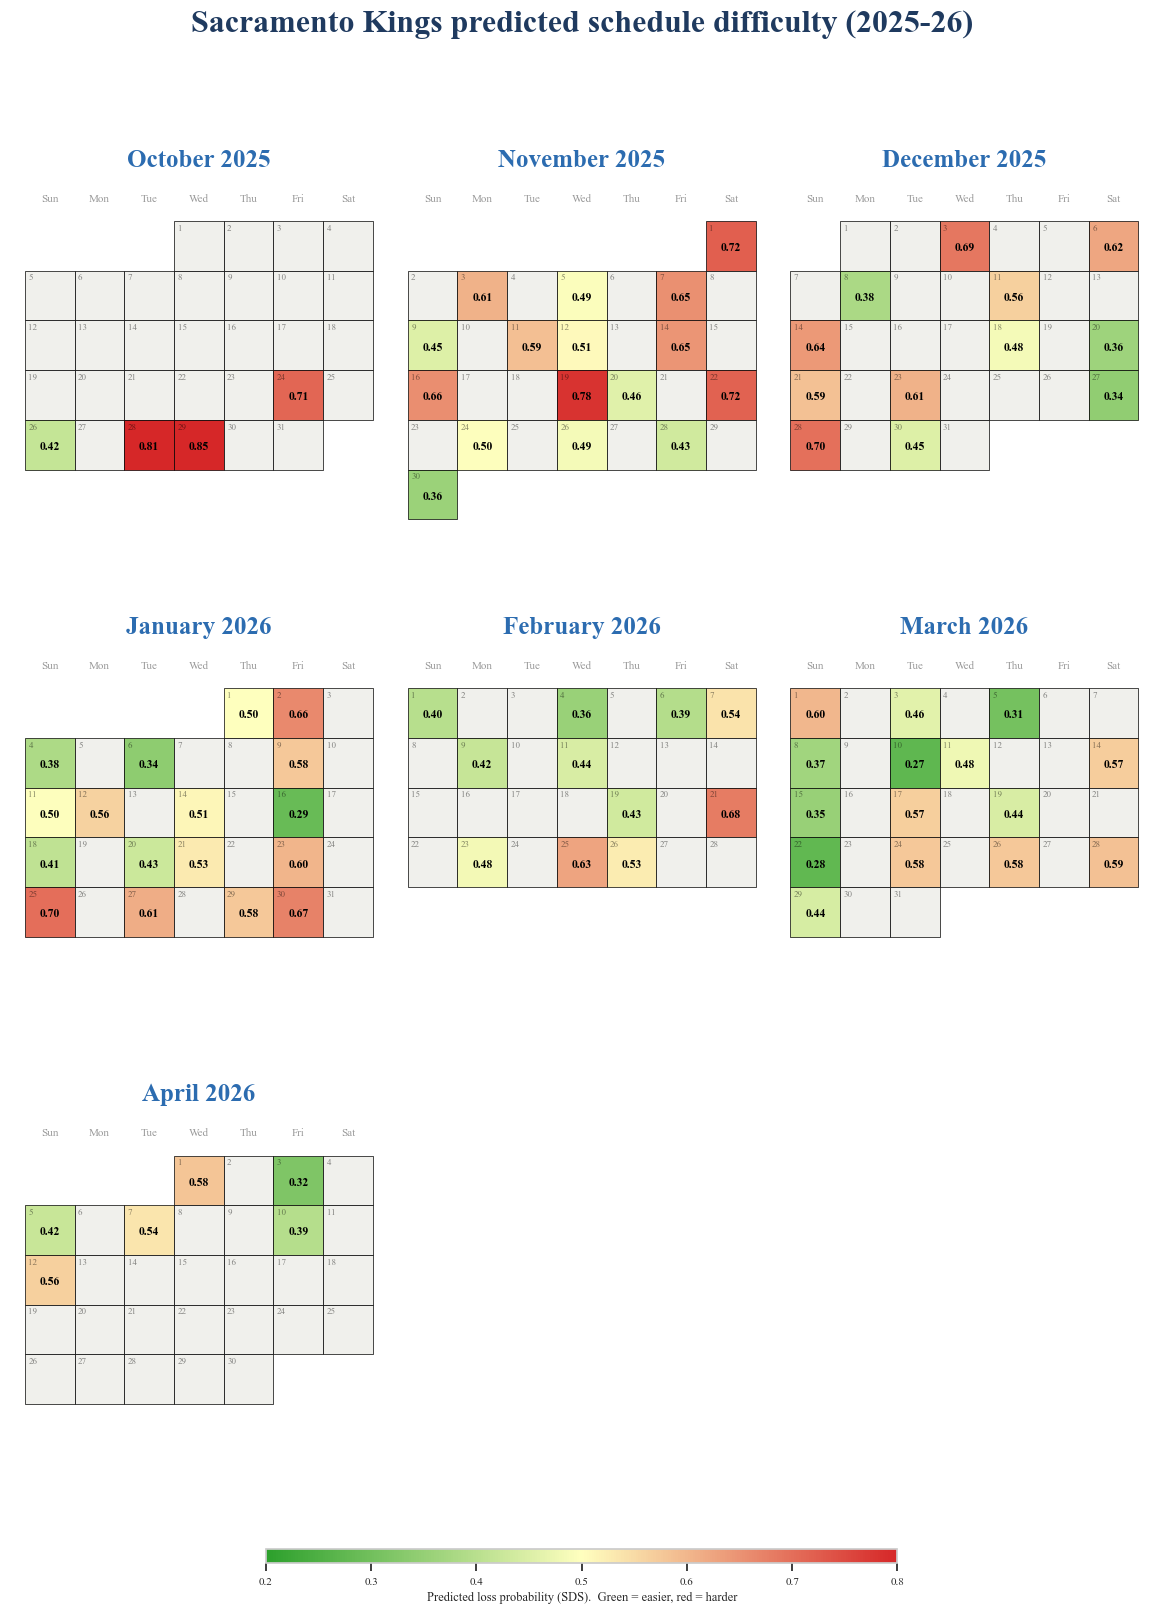

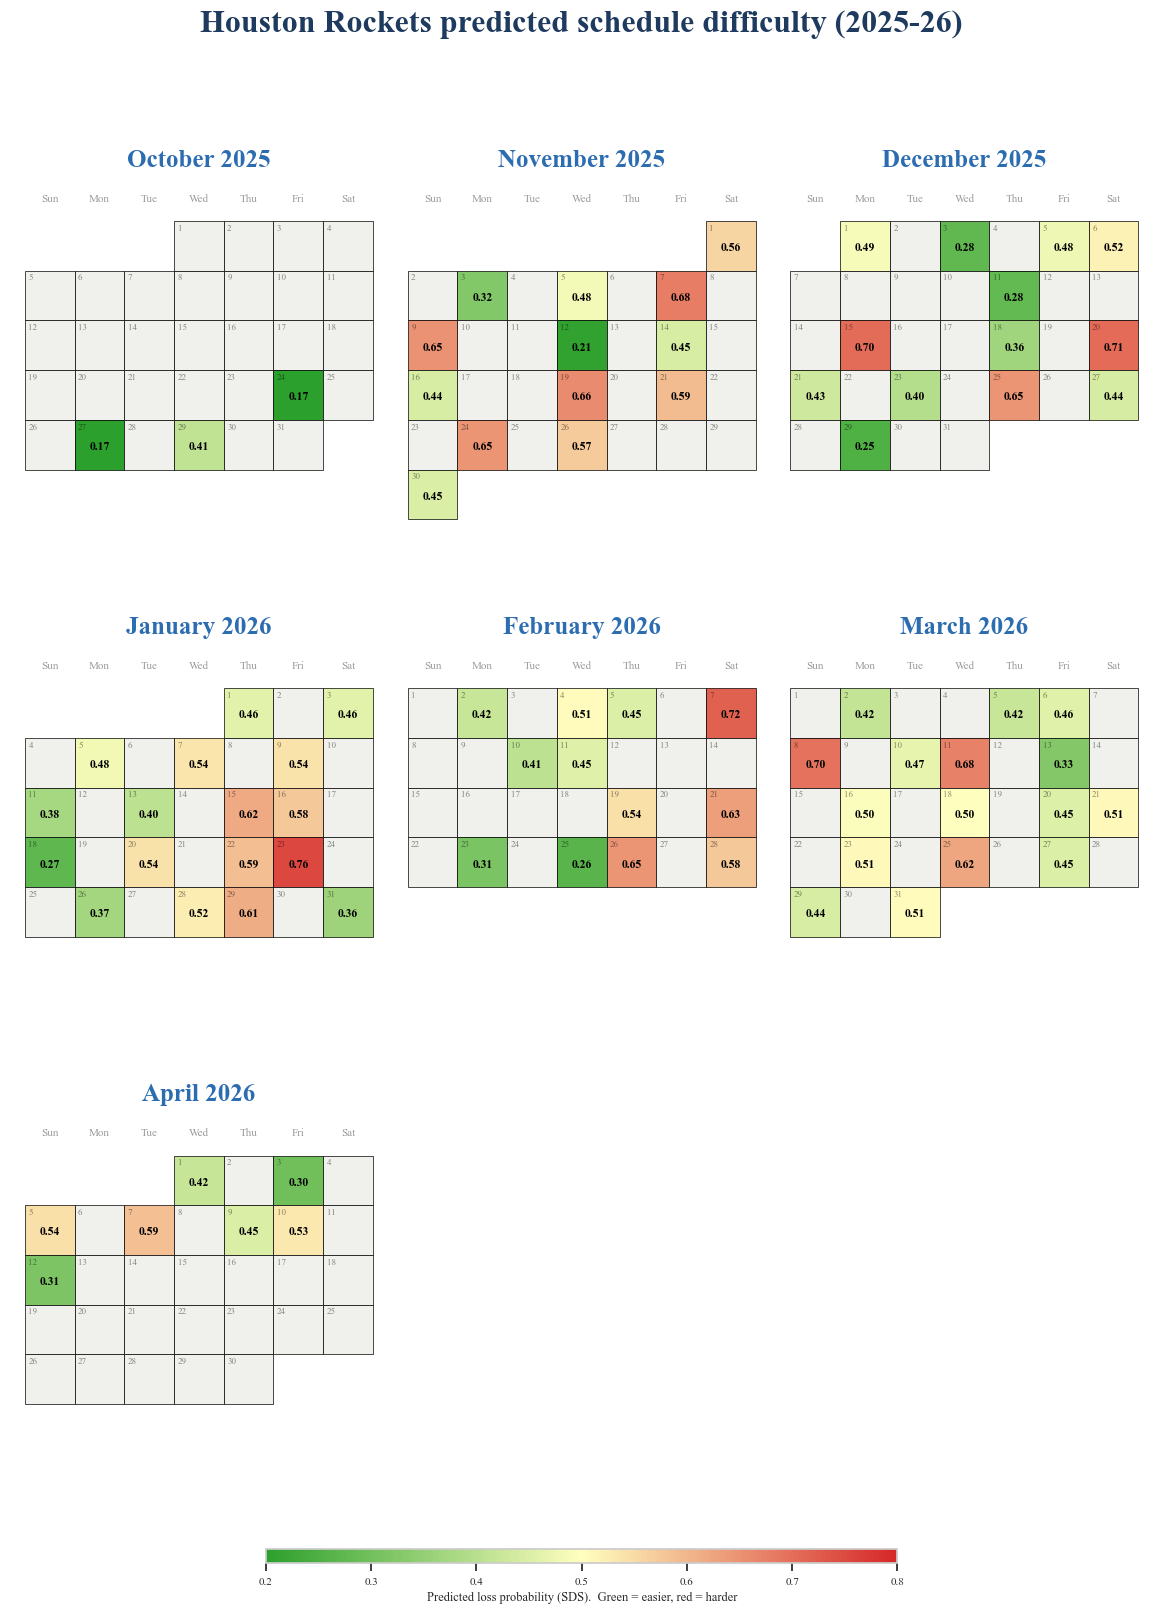

In [8]:
import calendar
import datetime
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

calendar.setfirstweekday(calendar.SUNDAY)
WEEKDAYS = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

SDS_CMAP = LinearSegmentedColormap.from_list('sds', ['#2ca02c', '#ffffbf', '#d62728'])

TEAM_NAMES = {
    'ATL': 'Atlanta Hawks', 'BOS': 'Boston Celtics', 'BKN': 'Brooklyn Nets',
    'CHA': 'Charlotte Hornets', 'CHI': 'Chicago Bulls', 'CLE': 'Cleveland Cavaliers',
    'DAL': 'Dallas Mavericks', 'DEN': 'Denver Nuggets', 'DET': 'Detroit Pistons',
    'GSW': 'Golden State Warriors', 'HOU': 'Houston Rockets', 'IND': 'Indiana Pacers',
    'LAC': 'LA Clippers', 'LAL': 'Los Angeles Lakers', 'MEM': 'Memphis Grizzlies',
    'MIA': 'Miami Heat', 'MIL': 'Milwaukee Bucks', 'MIN': 'Minnesota Timberwolves',
    'NOP': 'New Orleans Pelicans', 'NOH': 'New Orleans Hornets', 'NYK': 'New York Knicks',
    'OKC': 'Oklahoma City Thunder', 'ORL': 'Orlando Magic', 'PHI': 'Philadelphia 76ers',
    'PHX': 'Phoenix Suns', 'POR': 'Portland Trail Blazers', 'SAC': 'Sacramento Kings',
    'SAS': 'San Antonio Spurs', 'TOR': 'Toronto Raptors', 'UTA': 'Utah Jazz',
    'WAS': 'Washington Wizards',
}


def calendar_heatmap(team_scored, team_label, months_per_row=3):
    # one little calendar per month, each game day colored by its SDS
    df = team_scored.dropna(subset=['SDS']).copy()
    sds_by_date = {d.date(): s for d, s in zip(df['gamedate'], df['SDS'])}
    periods = sorted({(d.year, d.month) for d in df['gamedate']})

    GX, GY = 0.7, 1.4           # gaps between month blocks
    BW, BH = 7, 8               # 7 weekday cols; 1 title + 1 header + 6 week rows
    n_block_rows = -(-len(periods) // months_per_row)   # ceil
    total_w = months_per_row * (BW + GX) - GX
    total_h = n_block_rows * (BH + GY)

    norm = Normalize(vmin=0.2, vmax=0.8)
    fig, ax = plt.subplots(figsize=(total_w * 0.58, total_h * 0.58))

    for i, (yr, mo) in enumerate(periods):
        bc, br = i % months_per_row, i // months_per_row
        x0 = bc * (BW + GX)
        y0 = -br * (BH + GY)           # top of this month block

        ax.text(x0 + BW / 2, y0 - 0.6, calendar.month_name[mo] + f' {yr}', fontsize=18,
                weight='bold', ha='center', va='bottom', color='#2c6cb0')
        for c, wd in enumerate(WEEKDAYS):
            ax.text(x0 + c + 0.5, y0 - 1.15, wd, ha='center', va='center',
                    fontsize=8, color='#999')

        for w, week in enumerate(calendar.monthcalendar(yr, mo)):
            top = y0 - 1.6 - w         # top edge of this week's cells
            for c, day in enumerate(week):
                if day == 0:
                    continue
                cx = x0 + c
                sds = sds_by_date.get(datetime.date(yr, mo, day))
                face = SDS_CMAP(norm(sds)) if sds is not None else '#f0f0ec'
                ax.add_patch(Rectangle((cx, top - 1), 1, 1, facecolor=face,
                                       edgecolor='black', linewidth=0.5, zorder=0))
                ax.text(cx + 0.07, top - 0.07, str(day), ha='left', va='top',
                        fontsize=6.5, color=(0, 0, 0, 0.45), zorder=1)
                if sds is not None:
                    ax.text(cx + 0.5, top - 0.55, f'{sds:.2f}', ha='center', va='center',
                            fontsize=8.5, weight='bold', color='black', zorder=2)

    ax.set_xlim(-0.3, total_w + 0.3)
    ax.set_ylim(-total_h + 0.5, 1.6)
    ax.set_aspect('equal')
    ax.axis('off')
    full_name = TEAM_NAMES.get(team_label, team_label)
    ax.set_title(f'{full_name} predicted schedule difficulty ({score_season})',
                 fontsize=23, weight='bold', loc='center', color='#1f3a5f', pad=22)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=SDS_CMAP)
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03,
                        pad=0.02, aspect=45, shrink=0.5)
    cbar.set_label('Predicted loss probability (SDS).  Green = easier, red = harder',
                   fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    return ax


team_avg_sds = scored.groupby('team')['SDS'].mean().sort_values()
easiest_team = team_avg_sds.index[0]
hardest_team = team_avg_sds.index[-1]
print(f'Hardest {score_season} schedule (avg SDS): {hardest_team} ({team_avg_sds[hardest_team]:.3f})')
print(f'Easiest {score_season} schedule (avg SDS): {easiest_team} ({team_avg_sds[easiest_team]:.3f})')

for team_label in [hardest_team, easiest_team]:
    calendar_heatmap(scored[scored['team'] == team_label], team_label)
    plt.tight_layout()
    plt.show()


The two calendars above show how scheduling difficulty actually plays out in practice. The team with the highest average SDS faces a schedule with more road games, back-to-backs, and stronger opponents; the team with the lowest average SDS gets the opposite. Note that even the toughest team's typical game still hovers around a 50% loss probability, since opponent strength dominates inside any single matchup. The schedule moves the dial at the margins. In a league of the best basketball players in the world competing against and amongst each other, the margin can often be the deciding factor. Additionally, you have to consider that these athletes are used to constant travel for games, often since middle or high school. Still, sometimes the model predictions line up with the game results. During one of their toughest weeks of the season according to the model (1/25 to 1/30), SAC lost all four away games that the heatmap predicted they would lose. Overall, however, it is important to remember that this level of travel is familiar to most athletes, and they are expected to perform at their skill level whether they are home or away.

## Model Evaluation

Evaluated on the held-out 2025-26 season, which the model never saw during training. The model beats the baseline of always picking the home team to win by a small margin, which makes sense for a model built on scheduling factors alone. This further supports the conclusion that the role of scheduling is incredibly woven into the league and the sport. The SDS model predicts a game's outcome correctly 61% of the time, compared to 55% for simply always picking the home team and 50% for a coin flip.

In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score

eval_test = feats[feats['season'] == score_season].dropna(subset=ALL_FEATURES + ['win']).copy()
y_true = (1 - eval_test['win']).astype(int)            # 1 = loss
p_loss = model.predict_proba(eval_test[ALL_FEATURES])[:, 1]
y_pred = (p_loss >= 0.5).astype(int)
baseline = eval_test['is_away'].astype(int)            # always pick the home team to win

pd.DataFrame(
    {'Value': [f'{accuracy_score(y_true, y_pred) * 100:.1f}%',
               f'{roc_auc_score(y_true, p_loss):.3f}',
               f'{accuracy_score(y_true, baseline) * 100:.1f}%']},
    index=['Accuracy', 'ROC-AUC', 'Baseline (home team wins)'],
)


,Value
Accuracy,61.0%
ROC-AUC,0.655
Baseline (home team wins),55.3%


## Conclusion

The multicollinearity here is actually a feature, not a bug. Because the league has equalized rest and congestion so effectively, you can't separate schedule from team quality anymore. Overall, this project showed me truly how much multicollinearity exists in basketball data. Multicollinearity is the result of two independent variables having a strong relationship with each other, making the data uninterpretable or too nuanced to make a conclusion about. You'd expect the Knicks to win on a day trip to Philly after three rest days but lose the second game of a western road trip, but the data cannot support this with real confidence. There is an inseparable link between several of these measurable factors and somewhat immeasurable factors like rivalries, availability of training/resources in a given city, differences in attendance across arenas, and more. Still, I feel comfortable concluding from these variables and tests that the result of a game cannot be predicted with just these four variables. Travel's major role in the sports industry definitely has an effect on how players perform, but it changes the game for every team somewhat equally. Everyone in the league deals with constant travel in-season. If it's affecting one team's performance and not the other's, that's the competitive gap. To make an accurate hypothesis, however, you would need to both identify all factors that can influence a game prior to tip-off (many more than the ones I chose), and quantify or detangle the strong relationship these factors have to each other. For example, you might consider the length of a flight to the game and its impact on performance. However, all of these flights would be away games, making it hard to separate the away-game effect from the flight-length effect. This is where the multicollinearity is strongest in this project, and I hope in the future I can investigate this topic further considering these scopes and variables.

**Key Findings**

- A team's win probability swings from about 28% (a tired road game against a good team) to about 66% (a rested home game against a weak team) based purely on the schedule situation.
- Portland flies roughly 13,000 more miles per season than Cleveland, a structural travel gap geography won't let the league fix.
- The league measurably evened out congestion: each team's deviation from the league average in back-to-backs shrank about 45% (one-sided paired test, p=0.009). Travel did not significantly converge (p=0.07) because it is geographic.
- Across a full season, the schedule still barely changes win totals. Team quality dominates.

## Notes

- All game logs and schedules are from `nba_api.stats.endpoints.LeagueGameLog`, regular season only, 2013-14 through the most recent season. Graphs and models will automatically update upon completion of the 26-27 season.
- The SDS model uses logistic regression with standardized numeric features. Features and target definitions live in `features.py` and `model.py`.
- Travel distance is the great-circle miles between a team's consecutive game cities, computed from home-city coordinates hardcoded in `data.py`.
- Section Four uses a paired, one-sided Wilcoxon signed-rank test on each team's deviation from the league average, with three pre-specified directional hypotheses.